# Credit Scoring Model (German Credit Data)
CodeAlpha Machine Learning Internship, Task 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)

## 1. Load data\nThe German Credit dataset has 1,000 loan applicants and 20 features such as loan amount, duration, savings, job and age. Each person is labeled good or bad credit risk. It is downloaded automatically from OpenML.

In [2]:
credit = fetch_openml(name='credit-g', version=1, as_frame=True)
df = credit.frame.copy()

# 1 = bad credit risk (likely to default), 0 = good credit risk
df['default'] = (df['class'] == 'bad').astype(int)
df = df.drop(columns=['class'])

print(df.shape)
print(df['default'].value_counts())
df.head()

(1000, 21)
default
0    700
1    300
Name: count, dtype: int64


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,default
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,0
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,1
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,0
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,1


In [3]:
df.info()
print('Missing values:', df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

## 2. Feature engineering\nWe create new features from the financial history to give the model more signal.

In [4]:
df['credit_per_month'] = df['credit_amount'] / df['duration']        # monthly repayment burden
df['log_credit_amount'] = np.log1p(df['credit_amount'])               # reduces skew of large loans
df['long_loan'] = (df['duration'] > 24).astype(int)                   # loan longer than 24 months
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 120],
                         labels=['under25', '25to40', '41to60', 'over60']).astype(str)

df[['credit_per_month', 'log_credit_amount', 'long_loan', 'age_group']].head()

,credit_per_month,log_credit_amount,long_loan,age_group
0,194.833333,7.064759,0,over60
1,123.979167,8.691483,1,under25
2,174.666667,7.648263,0,41to60
3,187.666667,8.972464,1,41to60
4,202.916667,8.491055,0,41to60


## 3. Split and preprocess\nNumbers are scaled. Text categories are converted to 0/1 columns (one hot encoding).

In [5]:
X = df.drop(columns=['default'])
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()
print('Numeric columns:', len(num_cols), '| Category columns:', len(cat_cols))

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

Numeric columns: 10 | Category columns: 14


## 4. Train three models\n`class_weight='balanced'` is used because bad borrowers are only 30% of the data.

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
}

pipes, probs, results = {}, {}, []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    pipes[name], probs[name] = pipe, prob
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'ROC AUC': roc_auc_score(y_test, prob),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.755,0.5647,0.8000,0.6621,0.8088
Decision Tree,0.600,0.3913,0.6000,0.4737,0.6342
Random Forest,0.760,0.6875,0.3667,0.4783,0.8043


## 5. ROC curves

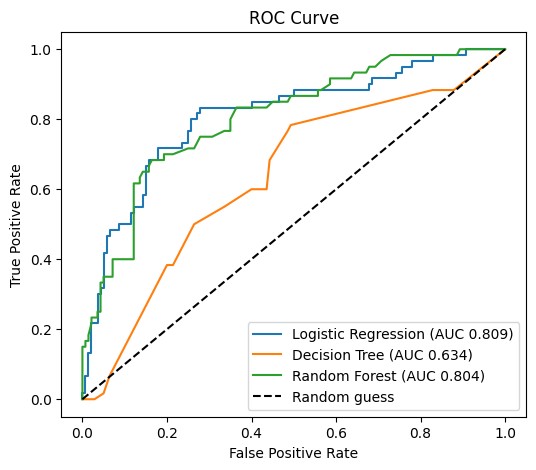

In [7]:
plt.figure(figsize=(6, 5))
for name, prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name + ' (AUC ' + str(round(roc_auc_score(y_test, prob), 3)) + ')')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 6. Confusion matrices

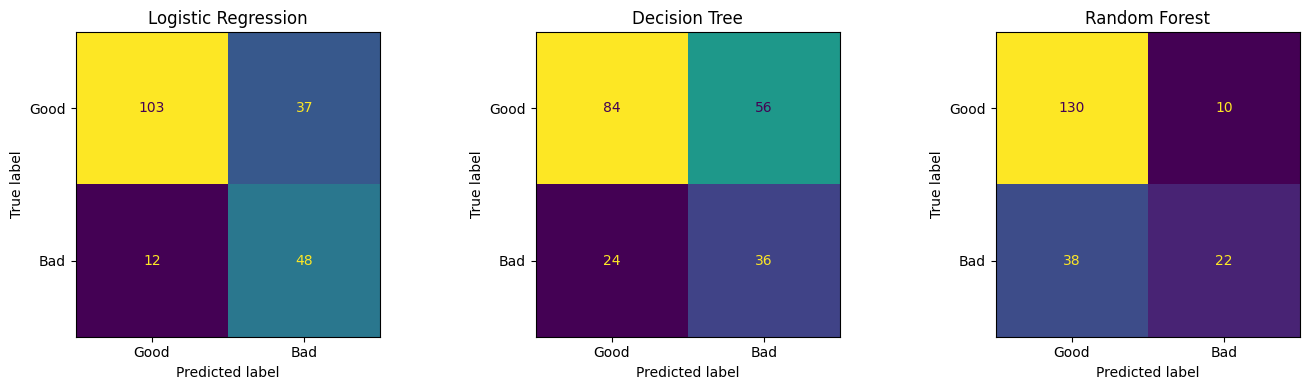

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pipe) in zip(axes, pipes.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['Good', 'Bad']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 7. Cross validation\nOnly 200 test rows is small, so we also check ROC AUC across 5 different splits.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    print(name, '-> mean AUC:', round(scores.mean(), 3), '+/-', round(scores.std(), 3))

Logistic Regression -> mean AUC: 0.785 +/- 0.018
Decision Tree -> mean AUC: 0.677 +/- 0.041
Random Forest -> mean AUC: 0.797 +/- 0.021


## 8. Which features matter most? (Random Forest)

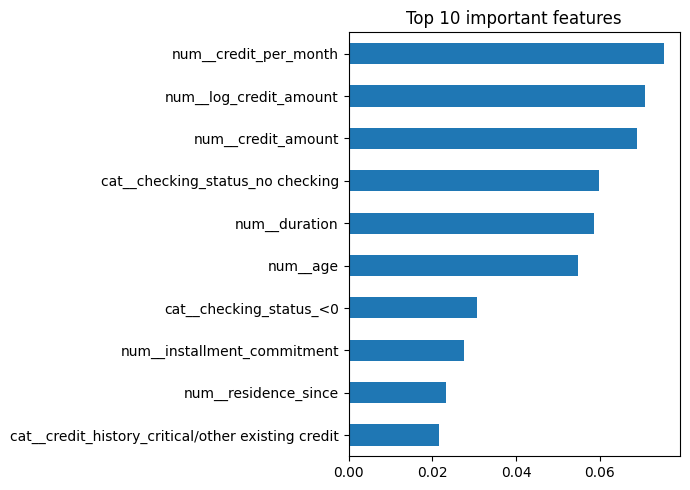

In [10]:
rf_pipe = pipes['Random Forest']
names = rf_pipe.named_steps['prep'].get_feature_names_out()
importance = rf_pipe.named_steps['model'].feature_importances_

top = pd.Series(importance, index=names).sort_values(ascending=False).head(10)
top[::-1].plot(kind='barh', figsize=(7, 5), title='Top 10 important features')
plt.tight_layout()
plt.show()

## 9. Threshold choice\nA bank loses more money from approving a bad borrower than from rejecting a good one. Lowering the threshold catches more bad borrowers (higher Recall) but rejects more good ones (lower Precision).

In [11]:
best_prob = probs['Logistic Regression']
rows = []
for t in [0.5, 0.4, 0.3]:
    pred_t = (best_prob >= t).astype(int)
    rows.append({'Threshold': t,
                 'Precision': precision_score(y_test, pred_t),
                 'Recall': recall_score(y_test, pred_t),
                 'F1 Score': f1_score(y_test, pred_t)})
pd.DataFrame(rows).set_index('Threshold').round(4)

,Precision,Recall,F1 Score
Threshold,,,
0.5,0.5647,0.8000,0.6621
0.4,0.4762,0.8333,0.6061
0.3,0.4262,0.8667,0.5714
